# Value-at-Risk via the Delta-Gamma Approximation

Let $(\Omega, \mathcal F, P)$ be the physical (statistical, not risk-neutral) probability space
on which the market actually evolves, and let $S = (S_1,\dots,S_m)$ be the vector of underlying
asset prices. Fix a risk horizon $\Delta t$ (e.g. two weeks) and let

$$
\Delta S = S(t+\Delta t) - S(t)
$$

be the $\mathcal F_{t+\Delta t}$-measurable random vector of price changes over the horizon. A
portfolio with value process $V(S(t),t)$ has **loss**

$$
L = -\Delta V = -\big(V(S(t)+\Delta S,\,t+\Delta t) - V(S(t),t)\big),
$$

a real-valued random variable on $(\Omega,\mathcal F,P)$. For $p\in(0,1)$, the **Value-at-Risk**
at level $p$ over the horizon $\Delta t$ is the $(1-p)$-quantile of $L$,

$$
\mathrm{VaR}_p = \inf\{x : P(L > x) \le p\}.
$$

When $V$ is a nonlinear (e.g. option-containing) function of $S$, the exact law of $L$ has no
closed form in general, and $\mathrm{VaR}_p$ must be estimated. This notebook implements and
compares three estimators, following Glasserman, *Monte Carlo Methods in Financial Engineering*,
Sections 9.1-9.2: (i) full Monte Carlo revaluation, (ii) a semi-analytic transform-inversion
estimate based on a quadratic (delta-gamma) approximation to $L$, and (iii) a control-variate
estimator that uses (ii) to reduce the variance of (i).

## Portfolio

Following the worked example behind Glasserman's Figure 9.1: $m=10$ independent underlying assets,
each with volatility $\sigma_j = 0.40$, and a book that is short 10 calls and short 5 puts on each
asset, all struck at-the-money with $T=0.10$ years to expiry. The risk horizon is
$\Delta t = 0.04$ years ($\approx 2$ weeks). Prices, deltas, gammas, and thetas are the standard
Black-Scholes quantities; the portfolio's aggregate Greeks are the (short-weighted) sums across
the two option legs on each asset. Because each underlying's price only affects the options
written on *that* underlying, the portfolio's Hessian (Gamma matrix) is diagonal even before
any change of basis — a simplification specific to this example, not a general feature of
delta-gamma portfolios (a portfolio with multi-asset options, e.g. basket or spread options,
would have a genuinely non-diagonal $\Gamma$).

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq

rng = np.random.default_rng(0)

# ---- Portfolio: Glasserman Fig. 9.1 example ----
m = 10
S0 = np.full(m, 100.0)
sigma = np.full(m, 0.40)
r = 0.05
K = S0.copy()            # at-the-money
T = 0.10                 # years to expiry
dt = 0.04                # risk horizon (~2 weeks)
n_calls_short = 10
n_puts_short = 5

def bs_greeks(S, K, r, sigma, T, kind):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    pdf1 = norm.pdf(d1)
    if kind == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        delta = norm.cdf(d1)
        theta = -S*pdf1*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        theta = -S*pdf1*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)
    gamma = pdf1 / (S*sigma*np.sqrt(T))
    return price, delta, gamma, theta

def portfolio_value(S, tau):
    # Total portfolio value; S may be shape (m,) or (n, m). Sums the two short option legs
    # across all m independent underlyings to a single scalar (or length-n vector) value.
    call_p, *_ = bs_greeks(S, K, r, sigma, tau, 'call')
    put_p, *_ = bs_greeks(S, K, r, sigma, tau, 'put')
    V = -(n_calls_short*call_p + n_puts_short*put_p)
    return V.sum(axis=-1)

call_p, call_d, call_g, call_t = bs_greeks(S0, K, r, sigma, T, 'call')
put_p, put_d, put_g, put_t = bs_greeks(S0, K, r, sigma, T, 'put')

Delta = -(n_calls_short*call_d + n_puts_short*put_d)          # portfolio delta, per underlying
Gamma_diag = -(n_calls_short*call_g + n_puts_short*put_g)      # portfolio gamma, diagonal entries
Theta = -(n_calls_short*call_t + n_puts_short*put_t).sum()     # portfolio theta, scalar
V0 = portfolio_value(S0, T)

print(f"V0 = {V0:.4f}   Theta = {Theta:.4f}")
print(f"Delta (per asset) = {Delta[0]:.4f} (identical across assets by symmetry)")
print(f"Gamma (per asset) = {Gamma_diag[0]:.4f}")

V0 = -767.6065   Theta = 3882.0798
Delta (per asset) = -3.1139 (identical across assets by symmetry)
Gamma (per asset) = -0.4706


## The delta-gamma approximation and its diagonalization

The second-order Taylor expansion of $\Delta V$ in $\Delta S$ and $\Delta t$ gives the
**delta-gamma approximation**

$$
\Delta V \approx \frac{\partial V}{\partial t}\Delta t + \delta^\top \Delta S +
\tfrac12 \Delta S^\top \Gamma \Delta S, \qquad
\delta_i = \frac{\partial V}{\partial S_i}, \quad
\Gamma_{ij} = \frac{\partial^2 V}{\partial S_i \partial S_j},
$$

so that $L \approx -\Delta V$ is a quadratic function of $\Delta S$. Assume
$\Delta S \sim N(0,\Sigma_S)$. Write $\Delta S = \tilde C Z$ with $\tilde C\tilde C^\top = \Sigma_S$
(e.g. a Cholesky factor) and $Z\sim N(0,I_m)$. The matrix $-\tfrac12 \tilde C^\top\Gamma\tilde C$
is symmetric, hence orthogonally diagonalizable: $-\tfrac12\tilde C^\top\Gamma\tilde C = U\Lambda U^\top$
with $U$ orthogonal and $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_m)$. Setting
$C = \tilde C U$ preserves $CC^\top = \Sigma_S$ and diagonalizes the quadratic form. With
$b = -C^\top\delta$ and $a = -\Delta t\,\partial V/\partial t$,

$$
L \approx Q := a + \sum_{j=1}^m \big(b_j Z_j + \lambda_j Z_j^2\big). \tag{9.4}
$$

In this portfolio $\Sigma_S$ and $\Gamma$ are already diagonal (independent underlyings, no
cross-gamma), so $\tilde C = \mathrm{diag}(\mathrm{std}_j)$ already diagonalizes the quadratic
form and $U = I$; the general eigendecomposition step is trivial here but is implemented in
its general form below (only relying on $\Gamma$ being symmetric, which holds regardless of
portfolio composition).

In [2]:
# Sigma_S is diagonal here (independent underlyings); build it and diagonalize generally
# (via eigh on the symmetric matrix -1/2 * Ctilde^T Gamma Ctilde) rather than hard-coding
# the diagonal shortcut, so the code generalizes to a non-diagonal Gamma unchanged.
std_dS = S0*sigma*np.sqrt(dt)
Sigma_S = np.diag(std_dS**2)
Gamma = np.diag(Gamma_diag)          # full m x m Gamma matrix (off-diagonal zero here)

C_tilde = np.linalg.cholesky(Sigma_S)
M = -0.5 * C_tilde.T @ Gamma @ C_tilde
eigvals, U = np.linalg.eigh(M)        # M = U diag(eigvals) U^T, U orthogonal
lam = eigvals
C = C_tilde @ U
b = -C.T @ Delta
a = -dt*Theta

print("a =", a)
print("lambda (first 3) =", lam[:3])
print("b (first 3)      =", b[:3])

a = -155.28319340100492
lambda (first 3) = [15.05905412 15.05905412 15.05905412]
b (first 3)      = [24.91146068 24.91146068 24.91146068]


## Distribution of $Q$: cumulant generating function and Fourier inversion

Because the summands in (9.4) are independent, the moment generating function factors. For
$\lambda_j=0$, $\psi_j(\theta)=\tfrac12 b_j^2\theta^2$; otherwise, completing the square identifies
$b_jZ_j+\lambda_jZ_j^2$ as an affine transform of a noncentral $\chi^2_1$ random variable, and the
standard noncentral-chi-square MGF gives the cumulant generating function

$$
\psi(\theta) = a\theta + \tfrac12\sum_{j=1}^m\left(\frac{\theta^2 b_j^2}{1-2\theta\lambda_j}
- \log(1-2\theta\lambda_j)\right), \qquad \max_j \theta\lambda_j < \tfrac12. \tag{9.5}
$$

The characteristic function is $\widehat\varphi(u) = E[e^{iuQ}] = e^{\psi(iu)}$, and the CDF of
$Q$ is recovered by the Gil-Pelaez-type inversion integral

$$
P(Q\le x) - P(Q \le x-y) = \frac1\pi\int_0^\infty
\mathrm{Re}\left[\widehat\varphi(u)\,\frac{e^{iuy}-1}{iu}\,e^{-iux}\right] du, \tag{9.6}
$$

choosing $y$ large enough that $P(Q\le x-y)\approx 0$. Because $\widehat\varphi$ decays extremely
fast away from $u=0$ (it is, up to the linear term, essentially a product of Gaussian-type
tilts), the integral must be evaluated with an adaptive quadrature that resolves this decay near
the origin — a fixed coarse grid silently produces a meaningless result (a value for
$P(Q\le x)$ outside $[0,1]$), since it fails to capture where almost all of the integrand's mass
actually lies.

In [3]:
def cgf(theta, lam=lam, b=b, a=a, m=m):
    theta = np.asarray(theta, dtype=complex)
    out = a*theta
    for j in range(m):
        if abs(lam[j]) < 1e-14:
            out = out + 0.5*b[j]**2*theta**2
        else:
            out = out + 0.5*(theta**2*b[j]**2/(1-2*theta*lam[j]) - np.log(1-2*theta*lam[j]))
    return out

def char_func(u):
    return np.exp(cgf(1j*np.asarray(u)))

def P_Q_greater(x, y=5000.0):
    def integrand(u):
        phi = char_func(np.array([u]))[0]
        val = phi * (np.exp(1j*u*y) - 1)/(1j*u) * np.exp(-1j*u*x)
        return val.real
    I, _ = quad(integrand, 0.0, 50.0, limit=400,
                points=[1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5, 1.0])
    return 1 - I/np.pi

# sanity: P(Q > x) must be a valid tail probability, decreasing from ~1 to ~0
print("P(Q > -1000) =", P_Q_greater(-1000.0))
print("P(Q > 1000)  =", P_Q_greater(1000.0))

# Delta-gamma semi-analytic VaR_0.99: solve P(Q > x) = 0.01 by bracketing + Brent's method
target = 0.01
f = lambda x: P_Q_greater(x) - target
xs = np.linspace(0.0, 3000.0, 30)
vals = [f(xv) for xv in xs]
bracket = next((xs[i], xs[i+1]) for i in range(len(xs)-1) if vals[i]*vals[i+1] < 0)
var_delta_gamma = brentq(f, *bracket, xtol=1e-2)
print(f"Delta-gamma semi-analytic VaR_0.99 (10-day-scale horizon): {var_delta_gamma:.4f}")

P(Q > -1000) = 1.000000000078933


P(Q > 1000)  = 8.459375755442977e-09


Delta-gamma semi-analytic VaR_0.99 (10-day-scale horizon): 290.8903


## Full Monte Carlo revaluation

The direct estimator simulates $\Delta S\sim N(0,\Sigma_S)$, revalues the *exact* portfolio
(Black-Scholes, no quadratic approximation) at $S+\Delta S$ under the shortened remaining
maturity $T-\Delta t$, and takes the empirical $(1-p)$-quantile of the simulated losses. This
is unbiased for the true VaR up to quantile-estimation error but requires a full repricing on
every replication.

In [4]:
n_mc = 200_000
Z = rng.standard_normal((n_mc, m))
dS = Z*std_dS
L = V0 - portfolio_value(S0 + dS, T - dt)

L_sorted = np.sort(L)
idx99 = int(np.ceil(0.99*n_mc)) - 1
var_mc = L_sorted[idx99]
se_mc = L.std(ddof=1)/np.sqrt(n_mc)

print(f"Full Monte Carlo VaR_0.99: {var_mc:.4f}  (n={n_mc}, loss std/sqrt(n) = {se_mc:.4f})")
print(f"Correlation(L, Q) = {np.corrcoef(L, a + Z@b + np.einsum('ij,j,ij->i', Z, lam, Z))[0,1]:.4f}")

Full Monte Carlo VaR_0.99: 272.1448  (n=200000, loss std/sqrt(n) = 0.2195)
Correlation(L, Q) = 0.9946


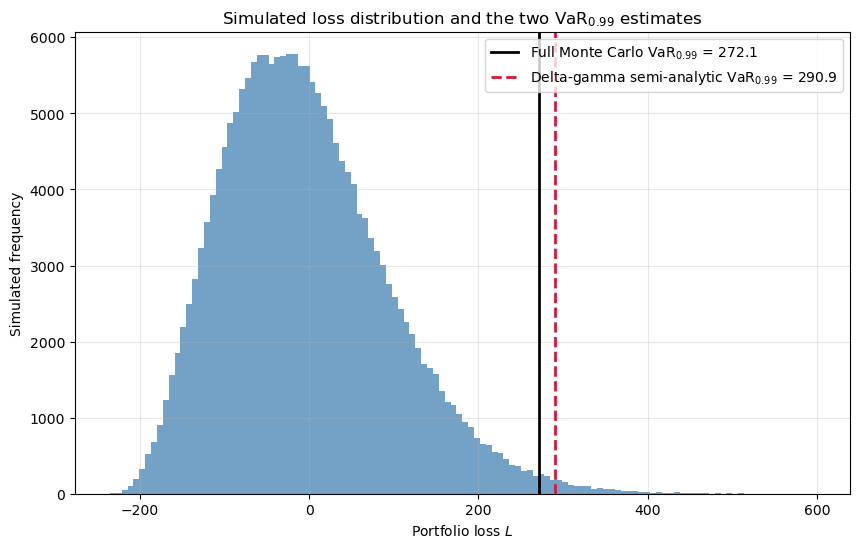

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(L, bins=120, color="steelblue", alpha=0.75, edgecolor="none")
ax.axvline(var_mc, color="black", linestyle="-", linewidth=2,
           label=f"Full Monte Carlo VaR$_{{0.99}}$ = {var_mc:.1f}")
ax.axvline(var_delta_gamma, color="crimson", linestyle="--", linewidth=2,
           label=f"Delta-gamma semi-analytic VaR$_{{0.99}}$ = {var_delta_gamma:.1f}")
ax.set_xlabel("Portfolio loss $L$")
ax.set_ylabel("Simulated frequency")
ax.set_title("Simulated loss distribution and the two VaR$_{0.99}$ estimates")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("var_loss_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Control-variate estimator using $Q$

Because $Q$ is available at negligible cost per replication (it is a closed-form quadratic in
the same $Z$ used to generate $\Delta S$) and is highly correlated with $L$, it serves as an
effective control variate for the loss-probability estimator (Glasserman eq. 9.9):

$$
1 - \widehat F^{cv}_L(x) = \frac1n\sum_{i=1}^n \mathbf 1\{L_i > x\}
- \widehat\beta\left(\frac1n\sum_{i=1}^n \mathbf 1\{Q_i > y\} - P(Q>y)\right),
$$

where $P(Q>y)$ is the *exact* tail probability from the transform inversion above (not
simulated), and $\widehat\beta$ is the empirical variance-minimizing coefficient
$\widehat{\mathrm{Cov}}(\mathbf 1\{L>x\},\mathbf 1\{Q>y\})/\widehat{\mathrm{Var}}(\mathbf 1\{Q>y\})$.
The maximum attainable variance reduction is $\rho^2$, where $\rho$ is the correlation between
the two indicator variables — necessarily smaller than $\mathrm{Corr}(L,Q)$ itself, since
thresholding a highly correlated pair need not preserve that correlation in the tails.

In [6]:
y_thresh = var_delta_gamma
P_y = P_Q_greater(y_thresh)

Q = a + Z@b + np.einsum('ij,j,ij->i', Z, lam, Z)
ind_L = (L > var_mc).astype(float)
ind_Q = (Q > y_thresh).astype(float)

cov_LQ = np.cov(ind_L, ind_Q)[0, 1]
var_Q = np.var(ind_Q)
beta_hat = cov_LQ/var_Q if var_Q > 0 else 0.0
p_hat_naive = ind_L.mean()
p_hat_cv = p_hat_naive - beta_hat*(ind_Q.mean() - P_y)

def batch_variance(vec, n_batches=50):
    n = len(vec); bs = n//n_batches
    means = [vec[i*bs:(i+1)*bs].mean() for i in range(n_batches)]
    return np.var(means, ddof=1)/n_batches

cv_vec = ind_L - beta_hat*(ind_Q - P_y)
var_naive = batch_variance(ind_L)
var_cv = batch_variance(cv_vec)
reduction_factor = var_naive/var_cv

print(f"P(Q > y) [exact, transform inversion] = {P_y:.6f}")
print(f"beta_hat = {beta_hat:.4f}")
print(f"Naive estimate of P(L > VaR_mc):        {p_hat_naive:.6f}")
print(f"Control-variate estimate of P(L > VaR_mc): {p_hat_cv:.6f}  (target 0.01)")
print(f"Variance reduction factor: {reduction_factor:.2f}x")

print()
print("Summary")
print("-------")
print(f"  Full Monte Carlo VaR_0.99:            {var_mc:8.4f}")
print(f"  Delta-gamma semi-analytic VaR_0.99:    {var_delta_gamma:8.4f}")
print(f"  Control-variate variance reduction:    {reduction_factor:8.2f}x")

P(Q > y) [exact, transform inversion] = 0.010000
beta_hat = 0.8610
Naive estimate of P(L > VaR_mc):        0.010000
Control-variate estimate of P(L > VaR_mc): 0.009479  (target 0.01)
Variance reduction factor: 5.98x

Summary
-------
  Full Monte Carlo VaR_0.99:            272.1448
  Delta-gamma semi-analytic VaR_0.99:    290.8903
  Control-variate variance reduction:        5.98x
